# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



In [57]:
# Set the URL
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [58]:
# Look at the headers
!curl -s -I {url}


HTTP/1.1 200 OK
x-amz-id-2: VJV6MW1f64WUgU2Qwe2oJ8Z/3JdBVPl6EVrJKhj4sgJYp7FeN0DWe078v0WmBKi+XQVOf63opNQ/L3lxfQGTNeSTuAFz/kxS
x-amz-request-id: 1YY3DBFBT2GSDQ0J
Date: Mon, 13 Jul 2026 01:21:04 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [59]:
# Download the file
!curl -s -O {url}


In [60]:
# Verify
!ls -la


total 740
drwxr-xr-x 1 root root   4096 Jul 12 23:50 .
drwxr-xr-x 1 root root   4096 Jul 12 23:44 ..
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 738124 Jul 13 01:21 Spotify.csv


In [61]:
# Look at the field names
!head -1 Spotify.csv | tr , '\n' | cat -n


     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


## IMPORT Libraries

In [62]:
# Load and inspect data
import pandas as pd
import numpy as np


Create Dataframe df

In [63]:

df = pd.read_csv('Spotify.csv')

# Quick inspection

print(df.head())



   Index  Highest Charting Position  Number of Times Charted  \
0      1                          1                        8   
1      2                          2                        3   
2      3                          1                       11   
3      4                          3                        5   
4      5                          5                        1   

  Week of Highest Charting                          Song Name     Streams  \
0   2021-07-23--2021-07-30                            Beggin'  48,633,449   
1   2021-07-23--2021-07-30          STAY (with Justin Bieber)  47,248,719   
2   2021-06-25--2021-07-02                           good 4 u  40,162,559   
3   2021-07-02--2021-07-09                         Bad Habits  37,799,456   
4   2021-07-23--2021-07-30  INDUSTRY BABY (feat. Jack Harlow)  33,948,454   

           Artist Artist Followers                 Song ID  \
0        Måneskin          3377762  3Wrjm47oTz2sjIgck11l5e   
1   The Kid LAROI          2

In [64]:

print(df.describe())

             Index  Highest Charting Position  Number of Times Charted
count  1556.000000                1556.000000              1556.000000
mean    778.500000                  87.744216                10.668380
std     449.322824                  58.147225                16.360546
min       1.000000                   1.000000                 1.000000
25%     389.750000                  37.000000                 1.000000
50%     778.500000                  80.000000                 4.000000
75%    1167.250000                 137.000000                12.000000
max    1556.000000                 200.000000               142.000000


In [65]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

In [66]:
# Check for missing values
print(df.isnull().sum())



Index                        0
Highest Charting Position    0
Number of Times Charted      0
Week of Highest Charting     0
Song Name                    0
Streams                      0
Artist                       0
Artist Followers             0
Song ID                      0
Genre                        0
Release Date                 0
Weeks Charted                0
Popularity                   0
Danceability                 0
Energy                       0
Loudness                     0
Speechiness                  0
Acousticness                 0
Liveness                     0
Tempo                        0
Duration (ms)                0
Valence                      0
Chord                        0
dtype: int64


In [67]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Potential target columns:", numerical_cols)

Potential target columns: ['Index', 'Highest Charting Position', 'Number of Times Charted']


In [91]:
print(df['Streams'].head(10))
print("\nDtype:", df['Streams'].dtype)

0    48,633,449
1    47,248,719
2    40,162,559
3    37,799,456
4    33,948,454
5    30,071,134
6    29,356,736
7    26,951,613
8    25,030,128
9    24,551,591
Name: Streams, dtype: object

Dtype: object


In [92]:
print(df['Popularity'].head(10))
print("\nDtype:", df['Popularity'].dtype)

0    100
1     99
2     99
3     98
4     96
5     97
6     94
7     95
8     96
9     95
Name: Popularity, dtype: object

Dtype: object


In [93]:
print(df['Number of Times Charted'].head(10))
print("\nDtype:", df['Number of Times Charted'].dtype)

0     8
1     3
2    11
3     5
4     1
5    18
6    16
7    10
8     8
9    10
Name: Number of Times Charted, dtype: int64

Dtype: int64


In [94]:
print(df['Highest Charting Position'].head(10))
print("\nDtype:", df['Highest Charting Position'].dtype)

0    1
1    2
2    1
3    3
4    5
5    1
6    3
7    2
8    3
9    8
Name: Highest Charting Position, dtype: int64

Dtype: int64


In [95]:
print(df['Weeks Charted'].head(10))
print("\nDtype:", df['Weeks Charted'].dtype)

0    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
1    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
2    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
3    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
4                               2021-07-23--2021-07-30
5    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
6    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
7    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
8    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
9    2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
Name: Weeks Charted, dtype: object

Dtype: object


## Target Popularity
Could be streams, followers, plays or views.

## Column sort

### y candidates (post-release outcomes)
1. Popularity
2.  Number of Times Charted
3.	Streams
4.  Highest Charting Position
5.  Weeks Charted
### X (pre-release predictors)
1.   Artist  drop this column wont get clean distribution
2.   Artist Followers  is a better predictor of popularity
3.   Genre
4.   Release Date
5.   Danceability
6.	Energy
7.	Loudness
8.	Speechiness
9. Acousticness
10.  Liveness
11.  Tempo
12.  Duration (ms)
13.  Valence
14.  Chord
### Drop (IDs, redundant, or otherwise unusable)
1. Index is row number
2. Song Name is unique
3. Song Id is unique
4. Week of Highest Charting


In [82]:
# Examine potential targets
potential_targets = ['popularity'] + [col for col in df.columns
  if any(word in col.lower()
  for word in ['stream', 'view', 'play', 'rank', 'chart'])]

KeyError: 'popularity'

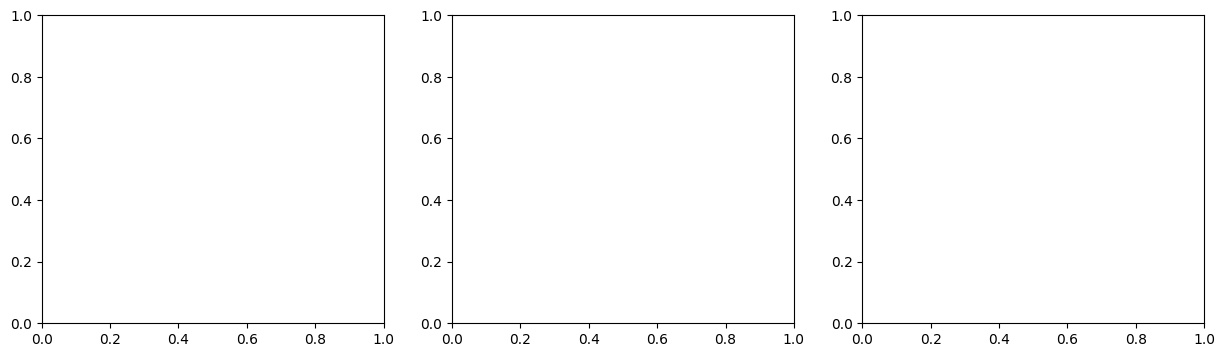

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check distribution of 'popularity'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['popularity'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity')

# Boxplot
sns.boxplot(y=df['potential_targets'], ax=axes[1])
axes[1].set_title('Popularity Boxplot')

# Check for outliers using IQR
Q1 = df['potential_targets'].quantile(0.25)
Q3 = df['potential_targets'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['potential_targets'] < Q1 - 1.5*IQR) | (df['potential_targets'] > Q3 + 1.5*IQR)]
print(f"Number of outlier songs: {len(outliers)}")